# BeakSpeak: Bird Data EDA

Importing libraries:

In [2]:
import kagglehub
import matplotlib.pyplot as plt
import os
import pandas as pd
import random
import seaborn as sns
import shutil

from PIL import Image


## Downloading the data

In [3]:
# Download latest version
path = kagglehub.dataset_download("veeralakrishna/200-bird-species-with-11788-images")

print("Path to dataset files:", path)

Path to dataset files: /Users/keira/.cache/kagglehub/datasets/veeralakrishna/200-bird-species-with-11788-images/versions/1


In [4]:
source_path = "/Users/keira/.cache/kagglehub/datasets/veeralakrishna/200-bird-species-with-11788-images/versions/1"
destination_path = "/Users/keira/code/keira-p/beakspeak/data"

# Create destination folder if it doesn't exist
os.makedirs(destination_path, exist_ok=True)

# Copy entire dataset
shutil.copytree(source_path, destination_path, dirs_exist_ok=True)

print("Dataset copied to project folder.")

Dataset copied to project folder.


## Checking out the data

How many species do we have?

In [5]:
images_path = "/Users/keira/code/keira-p/beakspeak/data/CUB_200_2011/CUB_200_2011/images"

species_folders = []

for item in os.listdir(images_path):
    if not item.startswith("."): # removes .DS_store hidden file
        species_folders.append(item)

len(species_folders)

200

How many images per species does the data contain?

In [6]:
# create empty dict to capture species image counts
counts = {}

for species in species_folders:

    # create full folder path
    species_path = os.path.join(images_path, species)

    # count number of files in each species folder and store in dict
    counts[species] = len(os.listdir(species_path))

# convert counts data into df
counts_df = pd.Series(counts)

# sort the Series by number of images (descending order)
counts_df = counts_df.sort_values(ascending=False)

counts_df.head()

137.Cliff_Swallow      60
128.Seaside_Sparrow    60
143.Caspian_Tern       60
014.Indigo_Bunting     60
092.Nighthawk          60
dtype: int64

In [7]:
counts_df.tail()

105.Whip_poor_Will       49
008.Rhinoceros_Auklet    48
018.Spotted_Catbird      45
005.Crested_Auklet       44
006.Least_Auklet         41
dtype: int64

In [8]:
counts_df.describe()

count    200.000000
mean      58.940000
std        2.918732
min       41.000000
25%       59.000000
50%       60.000000
75%       60.000000
max       60.000000
dtype: float64

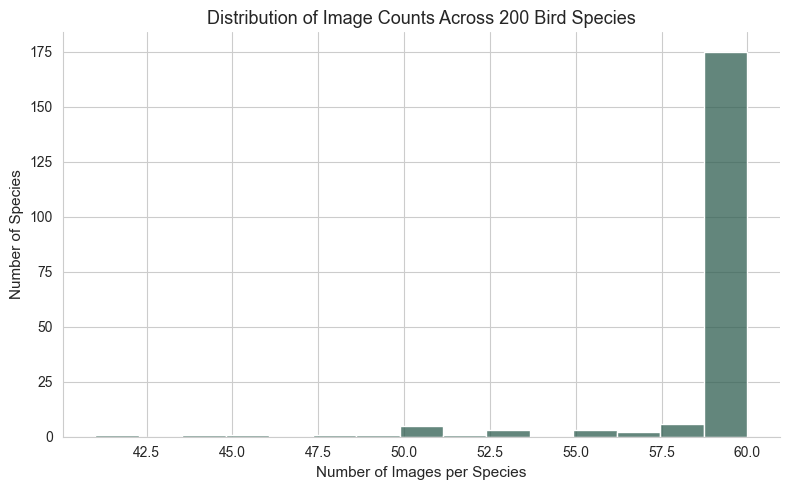

In [9]:
sns.set_style("whitegrid")

plt.figure(figsize=(8, 5))

sns.histplot(
    counts_df,
    bins=15,           # number of bins in histogram
    kde=False,         # no density curve
    color="#2F5D50"  # muted forest green (adjust if you like)
)

plt.xlabel("Number of Images per Species", fontsize=11)
plt.ylabel("Number of Species", fontsize=11)
plt.title("Distribution of Image Counts Across 200 Bird Species", fontsize=13)

sns.despine() # cleaner look

plt.tight_layout()
plt.show()

How many images are there in total?

In [10]:
total_images = counts_df.sum()
total_images

11788

What size are the images?

- CNNs need consistent sizes
- Transfer learning needs specific sizes

Quick spotcheck with a sample of 50 at random:

In [11]:
sample_sizes = []

for i in range(50):

     # select species at random and define folder path
     species = random.choice(species_folders)
     species_path = os.path.join(images_path, species)

     # pick a random image from that species and define image path
     image_name = random.choice(os.listdir(species_path))
     image_path = os.path.join(species_path, image_name)

     # open image and record size
     with Image.open(image_path) as img:
         sample_sizes.append(img.size)

sample_sizes[:10]

[(500, 375),
 (500, 500),
 (363, 500),
 (500, 375),
 (369, 500),
 (357, 500),
 (500, 369),
 (328, 500),
 (375, 500),
 (397, 500)]

👉 We'll need to resize.

NB 224×224 is standard for MobileNet / ResNet CNN models.

**What do the images look like?**

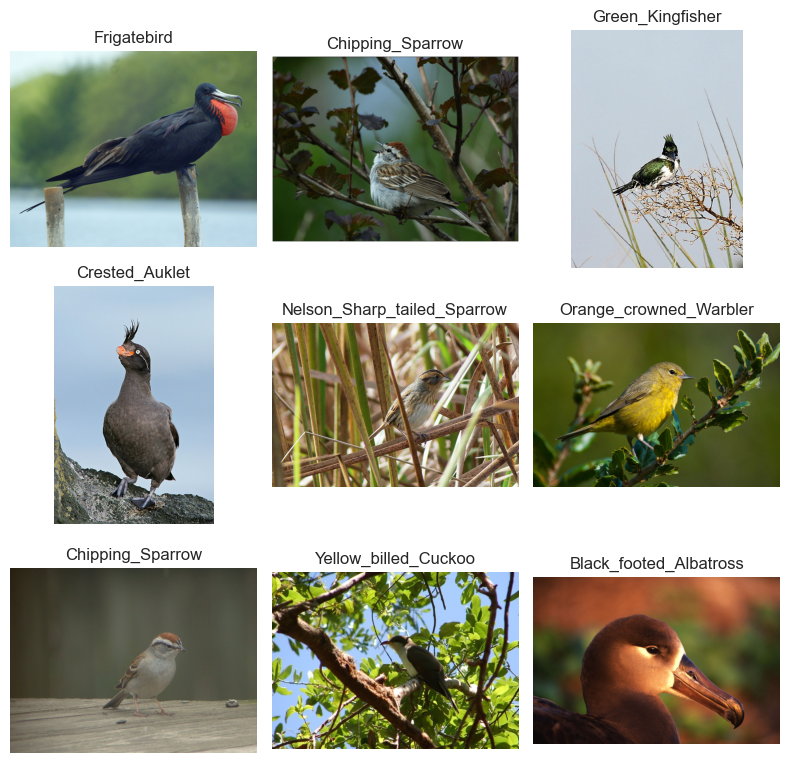

In [12]:
plt.figure(figsize=(8, 8))

for i in range(9):
    species = random.choice(species_folders)
    species_path = os.path.join(images_path, species)
    image_name = random.choice(os.listdir(species_path))
    image_path = os.path.join(species_path, image_name)

    img = Image.open(image_path)

    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.title(species.split('.')[1])
    plt.axis("off")

plt.tight_layout()
plt.show()

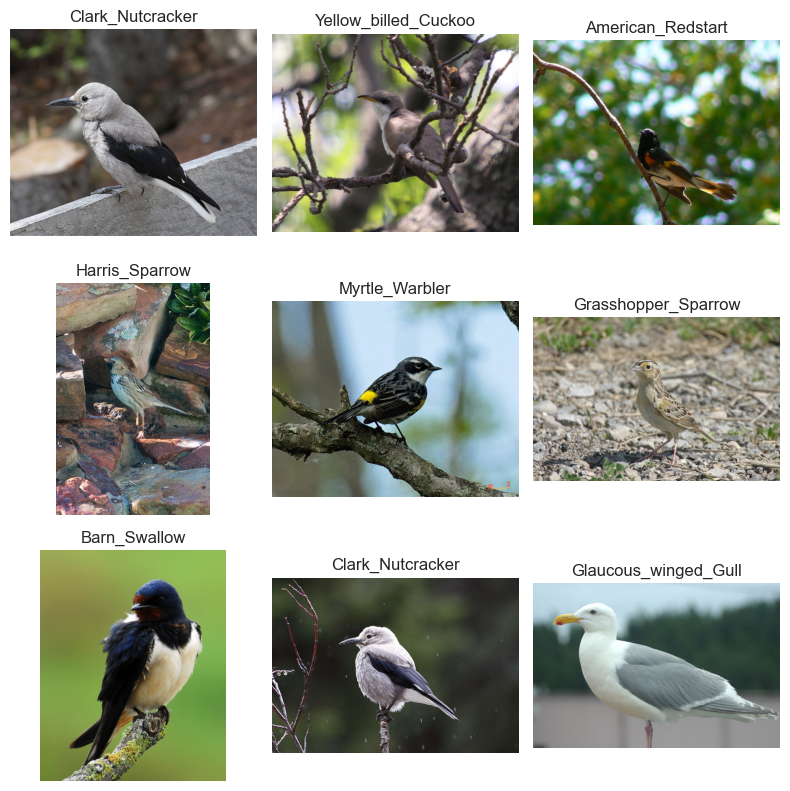

In [13]:
plt.figure(figsize=(8, 8))

for i in range(9):
    species = random.choice(species_folders)
    species_path = os.path.join(images_path, species)
    image_name = random.choice(os.listdir(species_path))
    image_path = os.path.join(species_path, image_name)

    img = Image.open(image_path)

    plt.subplot(3, 3, i+1)
    plt.imshow(img)
    plt.title(species.split('.')[1])
    plt.axis("off")

plt.tight_layout()
plt.show()

### Checking the train test split metadata

In [16]:
import pandas as pd

split = pd.read_csv(
    "data/CUB_200_2011/CUB_200_2011/train_test_split.txt",
    sep=" ",
    header=None
)

split.columns = ["image_id", "is_train"]

split.head()

,image_id,is_train
0,1,0
1,2,1
2,3,0
3,4,1
4,5,1


In [17]:
split["is_train"].value_counts()

is_train
1    5994
0    5794
Name: count, dtype: int64

In [18]:
len(split)

11788